In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import clhs as cl

In [107]:

roadsafe_df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_uuid_roadsafe.csv')

In [49]:
roadsafe_df.describe()

,lon,lat,sand_pct,clay_pct,total_silt_pct,fine_silt_pct,coarse_silt_pct,coarse_element_pct,ph_water,caco3_pct_total,...,p2o5_ehangable_olsen_ppm,mgo_ppm,cao_ppm,iron_ppm_dtpa,mn_ppm_dtpa,cu_ppm_dtpa,zn_ppm_dtpa,b_ppm_hot_water,depth_from_cm,depth_to_cm
count,47361.000000,47361.000000,16376.000000,16312.000000,16538.000000,16536.000000,14147.000000,10765.000000,47361.000000,17866.000000,...,47338.000000,12522.000000,2526.000000,18251.000000,18252.000000,15987.000000,18250.000000,14140.000000,47361.000000,47361.000000
mean,-6.407692,33.327868,42.409380,31.708742,27.089370,19.572992,8.947551,5.933395,7.842126,14.546826,...,51.930669,408.614119,499.151623,8.912042,21.731071,1.179192,1.229912,0.740513,1.691898,31.691898
std,1.715048,1.228364,24.655833,18.419510,12.199343,12.883742,4.585591,4.551016,0.852597,13.083856,...,60.555660,278.299433,268.718908,10.845682,28.511983,1.622075,3.380178,0.980919,6.920653,6.920653
min,-10.188600,28.139600,0.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.460000,0.000000,...,0.000000,0.000000,2.000000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,-7.748900,32.348500,22.000000,16.000000,20.000000,12.000000,5.000000,3.000000,7.610000,2.000000,...,15.000000,165.000000,318.000000,4.000000,6.100000,0.400000,0.300000,0.300000,0.000000,30.000000
50%,-6.234000,33.373200,38.000000,32.000000,26.000000,16.000000,8.000000,5.000000,8.050000,10.200000,...,30.000000,368.000000,502.500000,4.600000,12.200000,0.800000,0.600000,0.500000,0.000000,30.000000
75%,-5.386100,34.406900,61.000000,46.000000,33.000000,23.000000,13.000000,8.000000,8.310000,25.900000,...,65.000000,625.000000,714.750000,9.900000,24.400000,1.300000,1.300000,0.900000,0.000000,30.000000
max,-1.926400,35.896300,100.000000,97.000000,88.000000,86.000000,34.000000,85.000000,10.300000,91.500000,...,867.000000,999.000000,999.000000,220.200000,315.300000,47.200000,268.100000,60.000000,30.000000,60.000000


In [108]:
# Print number of lines before filtering
before_lines = len(roadsafe_df)

# Filter: keep all rows where Sand%, Clay%, and Total_Silt% are null,
# or all are non-null and non-negative and sum to 100

mask = (
    roadsafe_df[['sand_pct', 'clay_pct', 'total_silt_pct']].isnull().any(axis=1)
    |
    (
        (roadsafe_df['sand_pct'] >= 0)
        & (roadsafe_df['clay_pct'] >= 0)
        & (roadsafe_df['total_silt_pct'] >= 0)
        & (roadsafe_df[['sand_pct', 'clay_pct', 'total_silt_pct']].sum(axis=1) == 100)
    )
)

roadsafe_df = roadsafe_df[mask]

# Print number of lines after filtering
after_lines = len(roadsafe_df)
print(f"Number of lines before: {before_lines}")
print(f"Number of lines after: {after_lines}")

Number of lines before: 47361
Number of lines after: 45615


In [109]:
max_thresholds = {
    'ph_water': 9.5,
    'caco3_pct_total': 40,
    'caco3_active_pct': 25,
    'c_e_c_meq_100g': 200,
    'ce_ext1_5_ms_cm': 5,
    'na2o_ppm': 1500,
    'cl_ppm': 1500,
    'na_meq_100g': 0.7,
    'c_n_ratio': 100,
    'organic_matter_pct': 6.5,
    'mgo_ppm': 800,
    'cao_ppm': 3000,
    'iron_ppm_dtpa': 100,
    'cu_ppm_dtpa': 15,
    'zn_ppm_dtpa': 20,
    'b_ppm_hot_water': 2
}

In [110]:
# Print number of lines before filtering
before_filter = len(roadsafe_df)
print(f"Number of lines before threshold filtering: {before_filter}")

# Apply threshold filtering
for col, threshold in max_thresholds.items():
    if col in roadsafe_df.columns:
        roadsafe_df = roadsafe_df[
            (roadsafe_df[col].isna()) | (roadsafe_df[col] <= threshold)
        ]

#
after_filter = len(roadsafe_df)
print(f"Number of lines after threshold filtering: {after_filter}")

Number of lines before threshold filtering: 45615
Number of lines after threshold filtering: 40653


In [111]:
roadsafe_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40653 entries, 4 to 47359
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lon                       40653 non-null  float64
 1   lat                       40653 non-null  float64
 2   date                      40653 non-null  object 
 3   sand_pct                  10534 non-null  float64
 4   clay_pct                  10461 non-null  float64
 5   total_silt_pct            10677 non-null  float64
 6   fine_silt_pct             10675 non-null  float64
 7   coarse_silt_pct           8389 non-null   float64
 8   coarse_element_pct        7221 non-null   float64
 9   ph_water                  40653 non-null  float64
 10  caco3_pct_total           11828 non-null  float64
 11  caco3_active_pct          9432 non-null   float64
 12  c_e_c_meq_100g            10690 non-null  float64
 13  ce_ext1_5_ms_cm           13332 non-null  float64
 14  na2o_ppm   

In [112]:
# --- Configuration ---
VALIDATION_RULES = {
    'texture': {
        '>70%': {'ph_max': 7.8, 'caco3_min': 5},       # Calcareous sands
        '60-70%': {'ph_max': 8.2, 'caco3_min': 3},     # Loamy sands
        '<60%': {'ph_max': 8.9}                        # General soils
    },
    'absolute_limits': {
        'ph_absolute_max': 8.9,                        # Sodic soils threshold
        'om_ph_limit': (5, 8.3),                       # OM% >5 and pH >8.3
        'na_limit': 120                                # ppm
    }
}


TEXTURE_CEC = {
    'Sand': (3, 4.0), 'Loamy Sand': (5, 3.8), 'Sandy Loam': (10, 3.5),
    'Loam': (15, 3.2), 'Silt Loam': (18, 3.0), 'Sandy Clay Loam': (20, 2.8),
    'Silty Clay Loam': (25, 2.5), 'Clay Loam': (25, 2.2),
    'Sandy Clay': (30, 2.0), 'Silty Clay': (35, 1.8),
    'Clay': (40, 1.5), 'Unknown': (20, 2.5)
}

CEC_COL = 'c_e_c_meq_100g'


# --- Helper Functions ---
def classify_texture(sand, clay, silt):
    if any(pd.isna([sand, clay, silt])):
        return 'Unknown'
    total = sand + clay + silt
    if abs(total - 100) > 1:
        sand = (sand / total) * 100
        clay = (clay / total) * 100
        silt = (silt / total) * 100

    if silt + 1.5*clay < 15:
        return 'Sand'
    elif silt + 1.5*clay >= 15 and silt + 2*clay < 30:
        return 'Loamy Sand'
    elif (clay >= 7 and clay < 20) and sand > 52 and silt + 2*clay >= 30:
        return 'Sandy Loam'
    elif clay < 7 and silt < 50 and silt + 2*clay >= 30:
        return 'Loam'
    elif silt >= 50 and clay < 27:
        return 'Silt Loam'
    elif (clay >= 20 and clay < 35) and silt < 28 and sand > 45:
        return 'Sandy Clay Loam'
    elif clay >= 27 and clay < 40 and sand < 20:
        return 'Silty Clay Loam'
    elif clay >= 27 and clay < 40 and (20 <= sand <= 45):
        return 'Clay Loam'
    elif clay >= 35 and sand > 45:
        return 'Sandy Clay'
    elif clay >= 40 and silt >= 40:
        return 'Silty Clay'
    elif clay >= 40 and sand <= 45 and silt < 40:
        return 'Clay'
    else:
        return 'Unknown'

def calculate_expected_cec(row):
    sand, clay, silt = row.get('sand_pct'), row.get('clay_pct'), row.get('total_silt_pct')
    if any(pd.isna([sand, clay, silt])):
        return (None, None)
    
    texture = classify_texture(sand, clay, silt)
    base_cec, om_factor = TEXTURE_CEC.get(texture, (20, 2.5))
    om = row.get('organic_matter_pct')
    if pd.isna(om):
        return (None, None)

    om_contribution = om * om_factor
    expected_min = base_cec * 0.75 + om_contribution
    expected_max = base_cec * 1.25 + om_contribution
    abs_min = max(1, expected_min * 0.7)
    abs_max = expected_max * 1.3
    return (abs_min, abs_max)

def validate_row(row):
    """Return True if row violates any rules (ignoring NAs)."""
    sand = row.get('sand_pct')
    ph = row.get('pH_water')
    caco3 = row.get('caco3_pct_total')
    om = row.get('organic_matter_pct')
    na_meq = row.get('na_meq_100g')
    cec = row.get(CEC_COL)
    
    # Texture rule
    if pd.notna(sand) and pd.notna(ph):
        if sand > 70:
            if ph > VALIDATION_RULES['texture']['>70%']['ph_max'] and pd.notna(caco3):
                if caco3 < VALIDATION_RULES['texture']['>70%']['caco3_min']:
                    return True
        elif 60 <= sand <= 70:
            if ph > VALIDATION_RULES['texture']['60-70%']['ph_max'] and pd.notna(caco3):
                if caco3 < VALIDATION_RULES['texture']['60-70%']['caco3_min']:
                    return True
        else:
            if ph > VALIDATION_RULES['texture']['<60%']['ph_max']:
                return True

    # Absolute_pH max
    if pd.notna(ph) and ph > VALIDATION_RULES['absolute_limits']['ph_absolute_max']:
        return True

    # OM-pH paradox
    om_limit, ph_limit = VALIDATION_RULES['absolute_limits']['om_ph_limit']
    if pd.notna(om) and pd.notna(ph):
        if om > om_limit and ph > ph_limit:
            return True

    # Sodium hazard (convert meq to ppm)
    if pd.notna(ph) and pd.notna(na_meq):
        na_ppm = na_meq * 23 / 10
        if ph > 8.5 and na_ppm > VALIDATION_RULES['absolute_limits']['na_limit']:
            return True

    # CEC validation
    if pd.notna(cec):
        min_cec, max_cec = calculate_expected_cec(row)
        if min_cec is not None and max_cec is not None:
            if not (min_cec <= cec <= max_cec):
                return True

    return False


In [113]:
# Print total rows before filtering
total_rows_before = len(roadsafe_df)
print(f"Total rows before filtering: {total_rows_before}")

# Apply validation function
roadsafe_df['invalid'] = roadsafe_df.apply(validate_row, axis=1)

# Keep only conforming rows (where 'invalid' is False)
roadsafe_df_conforming = roadsafe_df[roadsafe_df['invalid'] == False].copy()

# Print total rows after filtering
total_rows_after = len(roadsafe_df_conforming)
print(f"Total rows after filtering: {total_rows_after}")

# Drop the temporary 'invalid' column
roadsafe_df_conforming.drop(columns='invalid', inplace=True)

Total rows before filtering: 40653
Total rows after filtering: 36293


In [114]:
cols = roadsafe_df_conforming.columns.tolist()
to_drop = {'lon', 'lat', 'date', 'depth_from_cm', 'depth_to_cm', 'uuid', 
           'ph_water', 'organic_matter_pct' 'exchangeable_k2o_ppm','p2o5_ehangable_olsen_ppm'
           }

# Rebuild the list, skipping the ones you don't want
filtered_cols = [c for c in cols if c not in to_drop]
filtered_cols

['sand_pct',
 'clay_pct',
 'total_silt_pct',
 'fine_silt_pct',
 'coarse_silt_pct',
 'coarse_element_pct',
 'caco3_pct_total',
 'caco3_active_pct',
 'c_e_c_meq_100g',
 'ce_ext1_5_ms_cm',
 'na2o_ppm',
 'cl_ppm',
 'na_meq_100g',
 'c_n_ratio',
 'organic_matter_pct',
 'exchangeable_k2o_ppm',
 'mgo_ppm',
 'cao_ppm',
 'iron_ppm_dtpa',
 'mn_ppm_dtpa',
 'cu_ppm_dtpa',
 'zn_ppm_dtpa',
 'b_ppm_hot_water']

In [115]:
roadsafe_df_conforming.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36293 entries, 4 to 47359
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lon                       36293 non-null  float64
 1   lat                       36293 non-null  float64
 2   date                      36293 non-null  object 
 3   sand_pct                  6174 non-null   float64
 4   clay_pct                  6101 non-null   float64
 5   total_silt_pct            6317 non-null   float64
 6   fine_silt_pct             6315 non-null   float64
 7   coarse_silt_pct           4635 non-null   float64
 8   coarse_element_pct        4201 non-null   float64
 9   ph_water                  36293 non-null  float64
 10  caco3_pct_total           7669 non-null   float64
 11  caco3_active_pct          5977 non-null   float64
 12  c_e_c_meq_100g            6330 non-null   float64
 13  ce_ext1_5_ms_cm           8972 non-null   float64
 14  na2o_ppm   

In [116]:
roadsafe_df_non_null = roadsafe_df_conforming[roadsafe_df_conforming['sand_pct'].notna()].copy()

In [117]:
roadsafe_df_indexed = roadsafe_df_conforming.set_index('sand_pct')

In [118]:
# set sample number
num_sample=6000
# cLHS
sampled=cl.clhs(roadsafe_df_non_null[filtered_cols], num_sample, max_iterations=1000)
clhs_sample=roadsafe_df_non_null.iloc[sampled["sample_indices"]]
# random sample, as a comparison
random_sample=roadsafe_df_non_null.sample(num_sample)

cLHS:100%|██████████|1000/1000 [Elapsed time: 11.208489894866943, ETA: 0.0, 89.22it/s]               


In [119]:
clhs_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 5574 to 1805
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lon                       6000 non-null   float64
 1   lat                       6000 non-null   float64
 2   date                      6000 non-null   object 
 3   sand_pct                  6000 non-null   float64
 4   clay_pct                  5771 non-null   float64
 5   total_silt_pct            5983 non-null   float64
 6   fine_silt_pct             5983 non-null   float64
 7   coarse_silt_pct           4417 non-null   float64
 8   coarse_element_pct        3933 non-null   float64
 9   ph_water                  6000 non-null   float64
 10  caco3_pct_total           5963 non-null   float64
 11  caco3_active_pct          5231 non-null   float64
 12  c_e_c_meq_100g            5996 non-null   float64
 13  ce_ext1_5_ms_cm           6000 non-null   float64
 14  na2o_ppm  

In [120]:
clhs_sample.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_soil_analysis_filtered_uuid_roadsafe_6ksample_validated.csv", index=False)

In [121]:
clhs_sample.head()

,lon,lat,date,sand_pct,clay_pct,total_silt_pct,fine_silt_pct,coarse_silt_pct,coarse_element_pct,ph_water,...,mgo_ppm,cao_ppm,iron_ppm_dtpa,mn_ppm_dtpa,cu_ppm_dtpa,zn_ppm_dtpa,b_ppm_hot_water,depth_from_cm,depth_to_cm,uuid
5574,-5.0080,33.6698,2020/01/18,35.0,29.0,36.0,27.0,9.0,3.0,7.95,...,NaN,NaN,4.0,27.0,0.5,0.9,0.7,0,30,653258ca-8f61-4e3f-91c5-f8f9dde6cb64
41270,-7.8510,33.1611,2019/10/10,73.0,11.0,16.0,9.0,8.0,1.0,6.24,...,330.0,NaN,43.6,143.5,1.3,0.6,0.5,0,30,63a31fed-b82e-4a9d-a05a-30490f7ac6d9
3084,-7.2030,31.8118,2019/12/21,49.0,24.0,27.0,20.0,8.0,4.0,8.21,...,610.0,NaN,4.0,12.3,0.7,0.4,0.5,0,30,2a402c07-ca76-4195-9ee1-2b8b98c19b6e
874,-4.3055,34.0209,2019/11/26,6.0,62.0,32.0,18.0,14.0,2.0,8.40,...,NaN,NaN,5.7,13.9,0.6,0.7,0.4,0,30,3990131b-7c10-4a05-ae04-0966a1e97657
4286,-9.4767,31.5540,2019/11/11,59.0,14.0,27.0,17.0,10.0,10.0,8.66,...,210.0,NaN,4.0,12.5,0.8,0.5,0.7,0,30,42f6ebe3-b99f-496a-bb59-0f91fa8e10d5


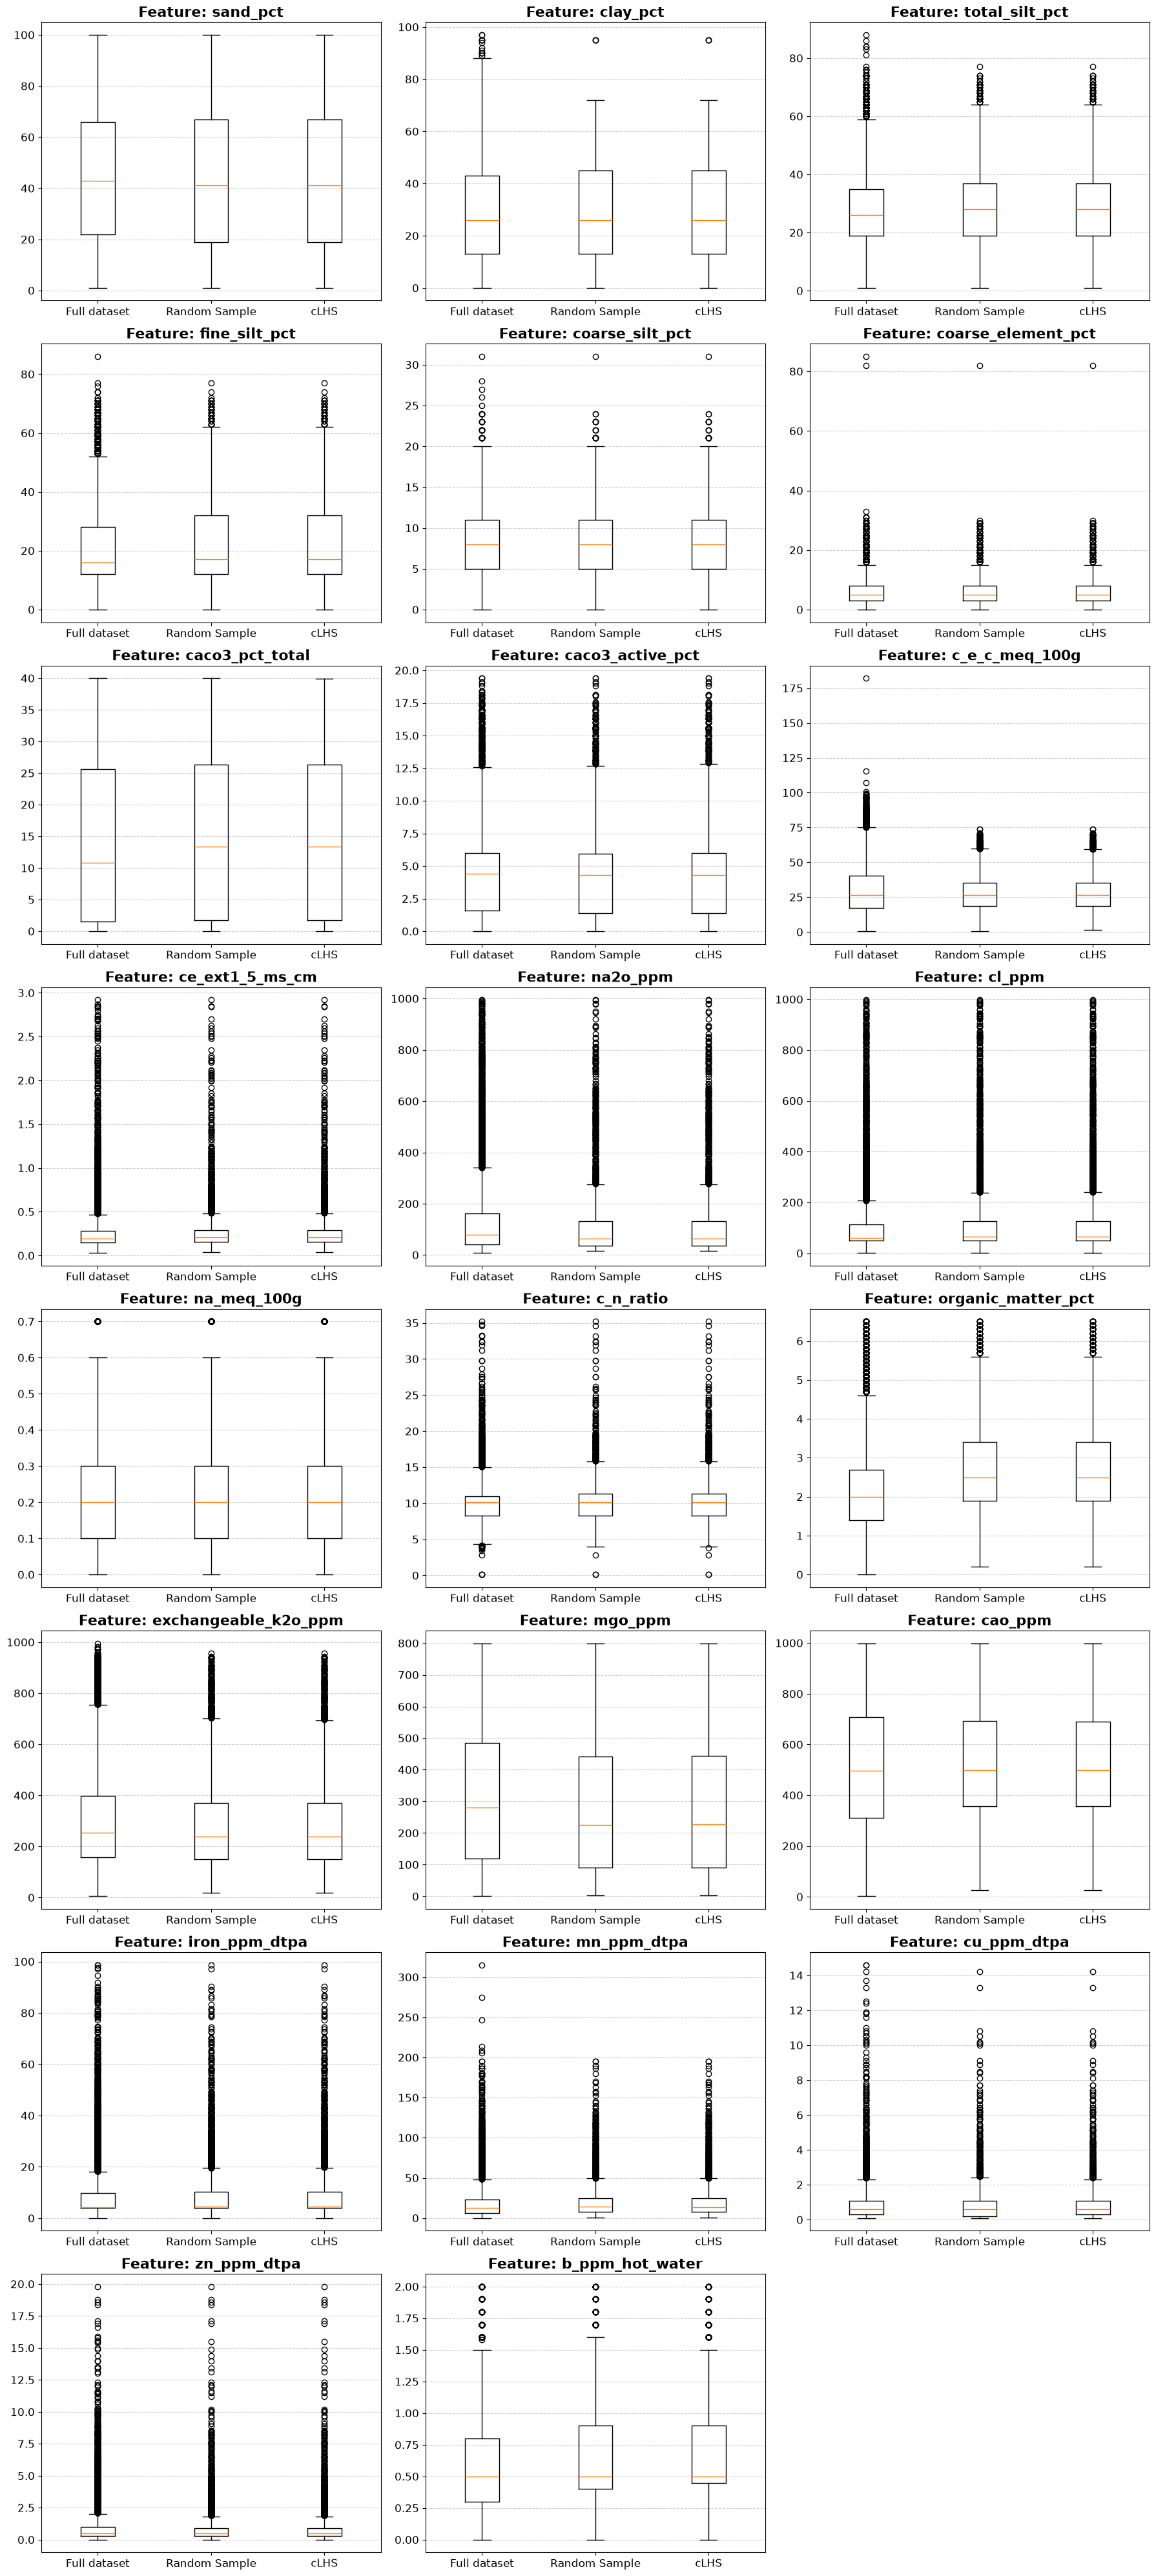

In [122]:
# --- NEW PLOTTING SECTION ---

# Calculate grid dimensions based on number of features
num_features = len(filtered_cols)
n_cols = 3  # You can change this to 2 or 4 depending on your screen width
n_rows = (num_features + n_cols - 1) // n_cols

# Create the figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten() # Flatten to iterate easily

# Global styling
matplotlib.rc('xtick', labelsize=12)
matplotlib.rc('ytick', labelsize=12)

for i, col in enumerate(filtered_cols):
    ax = axes[i]
    
    # Prepare the data for this specific feature
    # .dropna() is often good practice for boxplots to avoid errors
    data_to_plot = [
        roadsafe_df[col].dropna(),
        random_sample[col].dropna(),
        clhs_sample[col].dropna()
    ]
    
    # Create boxplot for the current feature
    ax.boxplot(data_to_plot, tick_labels=['Full dataset', 'Random Sample', 'cLHS'])
    
    # Set titles and formatting
    ax.set_title(f"Feature: {col}", fontsize=16, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Hide any empty subplots (if num_features isn't a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [123]:
static_df = pd.read_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features_and_covariates_V_110826.csv")

In [124]:
# Keep only rows in static_df whose UUIDs are present in clhs_sample
static_df_clhs = static_df[static_df['uuid'].isin(clhs_sample['uuid'])].copy()
static_df_clhs.to_csv("/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features_and_covariates_V_110826_clhs_sample.csv", index=False)